## ML Algoritmalarının karşılaştırması

In [ ]:
import os

os.listdir("data")

['heart_failure_clinical_records_dataset.csv']

In [ ]:
import pandas as pd

df = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Accuracy: 0.8166666666666667
F1 Score: 0.6666666666666666
              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60



In [ ]:
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

=== XGBoost ===
Accuracy: 0.8166666666666667
F1 Score: 0.6451612903225806
              precision    recall  f1-score   support

           0       0.81      0.95      0.88        41
           1       0.83      0.53      0.65        19

    accuracy                           0.82        60
   macro avg       0.82      0.74      0.76        60
weighted avg       0.82      0.82      0.80        60



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:12:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))

LR Accuracy: 0.8166666666666667
XGB Accuracy: 0.8166666666666667


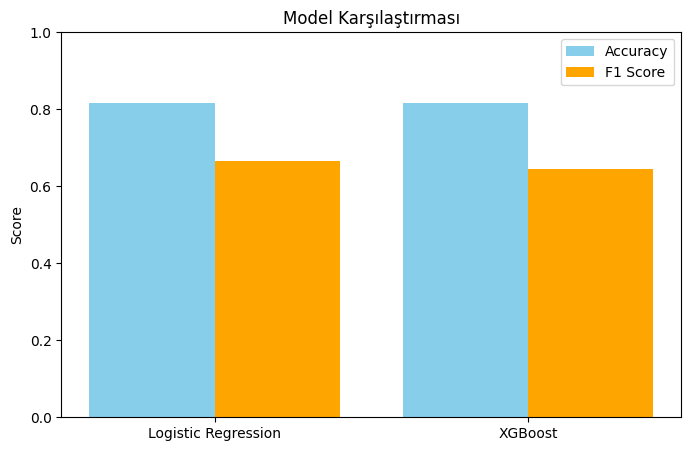

In [ ]:
import matplotlib.pyplot as plt

# skorları hesapla
lr_acc = accuracy_score(y_test, lr_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

lr_f1 = f1_score(y_test, lr_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

# değerler
models = ["Logistic Regression", "XGBoost"]

accuracy_scores = [lr_acc, xgb_acc]
f1_scores = [lr_f1, xgb_f1]

# grafik
x = range(len(models))

plt.figure(figsize=(8,5))

plt.bar(x, accuracy_scores, width=0.4, label="Accuracy", color="skyblue", align="center")
plt.bar([i + 0.4 for i in x], f1_scores, width=0.4, label="F1 Score", color="orange", align="center")

plt.xticks([i + 0.2 for i in x], models)
plt.ylim(0, 1)

plt.title("Model Karşılaştırması")
plt.ylabel("Score")
plt.legend()

plt.show()

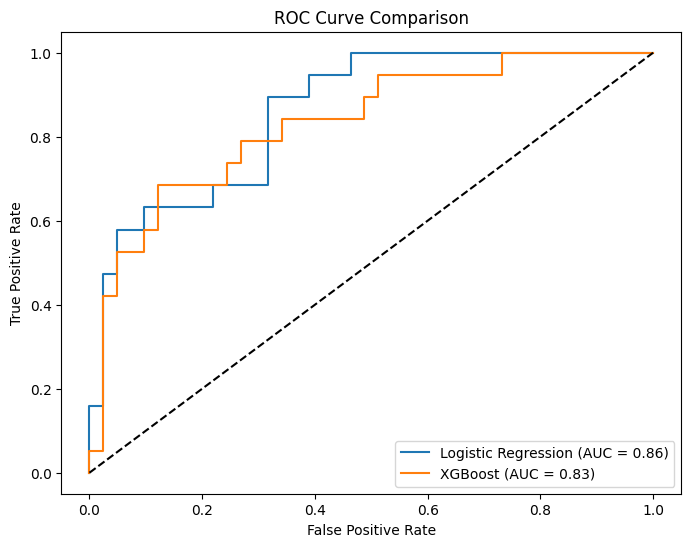

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression probability
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# XGBoost probability
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# ROC değerleri
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

# AUC
lr_auc = auc(lr_fpr, lr_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# Grafik
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.2f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.2f})")

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

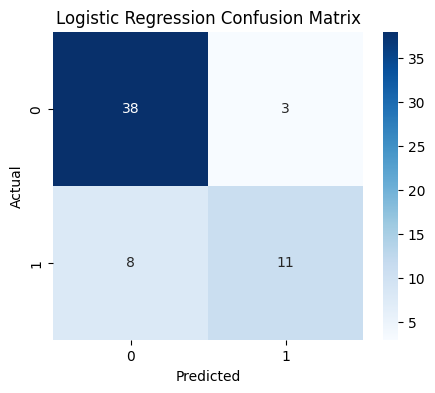

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm_lr,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

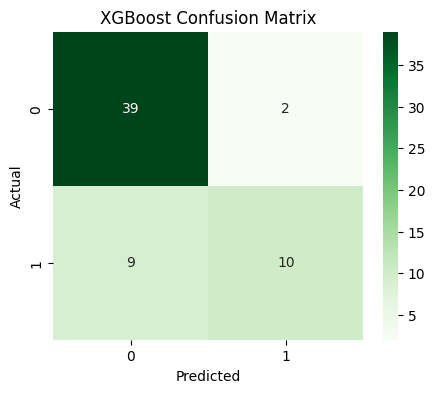

In [ ]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm_xgb,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

/tmp/ipykernel_29169/1638578752.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


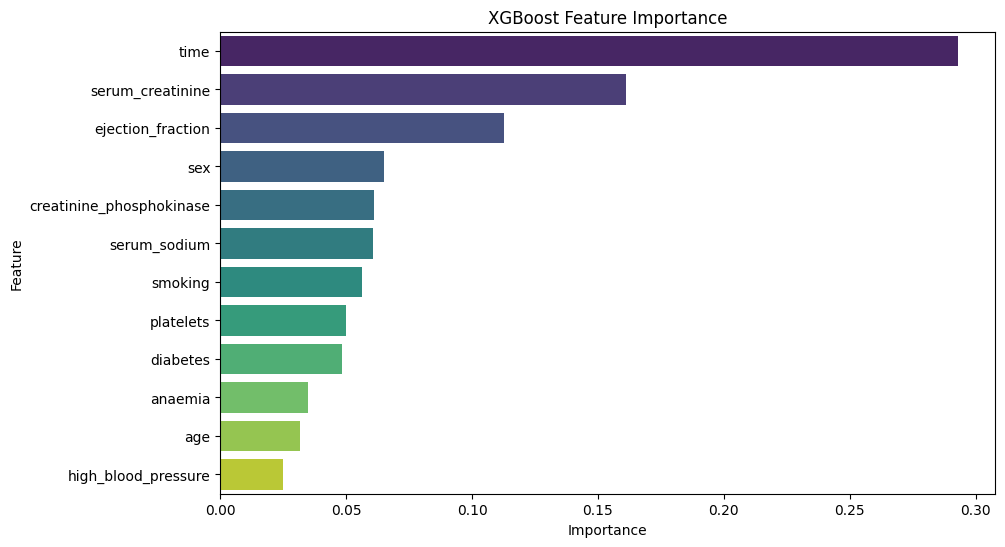

In [ ]:
import pandas as pd

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance,
    palette="viridis"
)

plt.title("XGBoost Feature Importance")

plt.show()